# Customer Personality Analysis (Clustering)

**Author:** Nijat Aghayev

### Description
This project focuses on customer segmentation. The main goal is to group customers based on their demographic information and purchasing behaviour, so that a business can better understand different customer types and make more targeted decisions.

This is an **unsupervised learning** problem. There is no target label, so the model has to find patterns in the data by itself. I use **K-Means clustering** and then analyse the resulting customer groups.

### Main workflow
1. Load and understand the dataset
2. Clean the data
3. Create useful customer-level features
4. Remove clear outliers
5. Explore important relationships in the data
6. Encode and scale the features
7. Choose the number of clusters using Elbow and Silhouette methods
8. Build the K-Means model
9. Visualize and profile the final customer segments


In [1]:
# Import libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 70   # keep embedded images light so the notebook renders everywhere
RANDOM_STATE = 42

## 1. Load the data

In [2]:
# The file is tab-separated
data = pd.read_csv("marketing_campaign.csv", sep="\t")
print("Shape:", data.shape)
data.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

## 2. Data cleaning

### 2.1 Missing values

In [4]:
print("Missing values per column:")
print(data.isnull().sum()[data.isnull().sum() > 0])

Missing values per column:
Income    24
dtype: int64


Only `Income` has missing values, with 24 missing rows. Since this is a small part of the full dataset, I remove those rows.

In [5]:
data = data.dropna().reset_index(drop=True)
print("Shape after dropping missing values:", data.shape)

Shape after dropping missing values: (2216, 29)


### 2.2 Removing constant columns

In [6]:
# Z_CostContact and Z_Revenue have the same value in every row,
# so they carry no information for the model.
print("Unique values in Z_CostContact:", data["Z_CostContact"].nunique())
print("Unique values in Z_Revenue   :", data["Z_Revenue"].nunique())
data = data.drop(columns=["Z_CostContact", "Z_Revenue"])

Unique values in Z_CostContact: 1
Unique values in Z_Revenue   : 1


## 3. Feature engineering

The raw dataset contains many columns that are easier to understand after creating more meaningful customer features:

- **Customer_For**: how long the customer has been enrolled, measured in days.
- **Age**: calculated from the birth year using the most recent year in the dataset.
- **Spent**: total amount spent across all product categories.
- **Living_With**: simplified relationship status, grouped as Alone or Partner.
- **Children**: total number of children at home.
- **Family_Size**: estimated family size based on relationship status and children.
- **Is_Parent**: shows whether the customer has children at home.

These features make the clustering results easier to interpret later.


In [7]:
# Enrollment date -> "Customer_For" in days
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], format="%d-%m-%Y")
newest = data["Dt_Customer"].max()
print("Newest enrollment date:", newest.date())
print("Oldest enrollment date:", data["Dt_Customer"].min().date())
data["Customer_For"] = (newest - data["Dt_Customer"]).dt.days

# Age relative to the most recent year in the dataset (avoids a hard-coded year)
ref_year = data["Dt_Customer"].dt.year.max()
data["Age"] = ref_year - data["Year_Birth"]

# Total spending across all product categories
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
data["Spent"] = data[mnt_cols].sum(axis=1)

# Simplify relationship status
data["Living_With"] = data["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Absurd": "Alone", "Widow": "Alone", "YOLO": "Alone",
    "Divorced": "Alone", "Single": "Alone"})

# Household features
data["Children"] = data["Kidhome"] + data["Teenhome"]
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner": 2}) + data["Children"]
data["Is_Parent"] = (data["Children"] > 0).astype(int)

# Collapse education into three levels
data["Education"] = data["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"})

data[["Age", "Spent", "Customer_For", "Living_With", "Children", "Is_Parent", "Education"]].head()

Newest enrollment date: 2014-06-29
Oldest enrollment date: 2012-07-30


,Age,Spent,Customer_For,Living_With,Children,Is_Parent,Education
0,57,1617,663,Alone,0,0,Graduate
1,60,27,113,Alone,2,1,Graduate
2,49,776,312,Partner,0,0,Graduate
3,30,53,139,Partner,1,1,Graduate
4,33,422,161,Partner,1,1,Postgraduate


## 4. Outlier handling

The summary statistics show a few unrealistic values, especially very high ages and extreme income values. I remove these clear outliers so they do not distort the distance-based clustering process.


In [8]:
print("Max age before:", data["Age"].max(), "| Max income before:", data["Income"].max())
before = len(data)
data = data[(data["Age"] < 90) & (data["Income"] < 600000)].reset_index(drop=True)
print("Rows removed:", before - len(data))
print("Shape after outlier removal:", data.shape)

Max age before: 121 | Max income before: 666666.0
Rows removed: 4
Shape after outlier removal: (2212, 34)


## 5. EDA (Exploratory Data Analysis)

In [9]:
data[["Income", "Age", "Spent", "Recency", "Children"]].describe()

,Income,Age,Spent,Recency,Children
count,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000
mean,51958.810579,45.086347,607.268083,49.019439,0.947559
std,21527.278844,11.701599,602.513364,28.943121,0.749466
min,1730.000000,18.000000,5.000000,0.000000,0.000000
25%,35233.500000,37.000000,69.000000,24.000000,0.000000
50%,51371.000000,44.000000,397.000000,49.000000,1.000000
75%,68487.000000,55.000000,1048.000000,74.000000,1.000000
max,162397.000000,74.000000,2525.000000,99.000000,3.000000


### 5.1 Income and spending

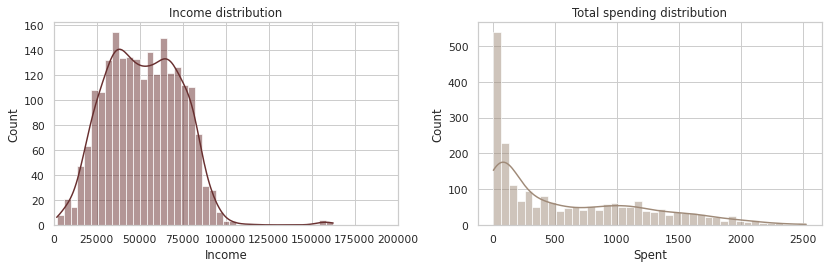

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data["Income"], bins=40, kde=True, ax=ax[0], color="#682F2F")
ax[0].set_title("Income distribution"); ax[0].set_xlim(0, 200000)
sns.histplot(data["Spent"], bins=40, kde=True, ax=ax[1], color="#9F8A78")
ax[1].set_title("Total spending distribution")
plt.tight_layout(); plt.show()

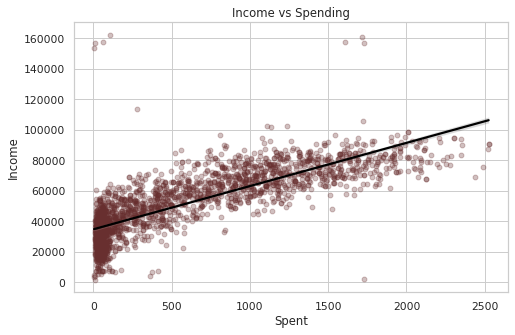

In [11]:
plt.figure(figsize=(8, 5))
sns.regplot(x="Spent", y="Income", data=data,
            scatter_kws={"color": "#682F2F", "s": 25, "alpha": 0.3},
            line_kws={"color": "black"})
plt.title("Income vs Spending")
plt.show()

**Insight:** Income and spending have a strong positive relationship. In general, customers with higher income also spend more. This is one of the main patterns that the clustering model should capture.

### 5.2 Education and family

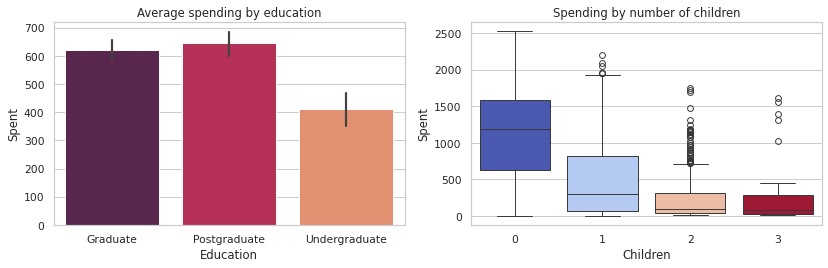

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x="Education", y="Spent", data=data, hue="Education",
            palette="rocket", legend=False, ax=ax[0])
ax[0].set_title("Average spending by education")
sns.boxplot(x="Children", y="Spent", data=data, hue="Children",
            palette="coolwarm", legend=False, ax=ax[1])
ax[1].set_title("Spending by number of children")
plt.tight_layout(); plt.show()

**Insight:** More educated customers tend to spend more, while customers with more children usually spend less. This suggests that family situation is an important factor for segmentation.

### 5.3 Correlations

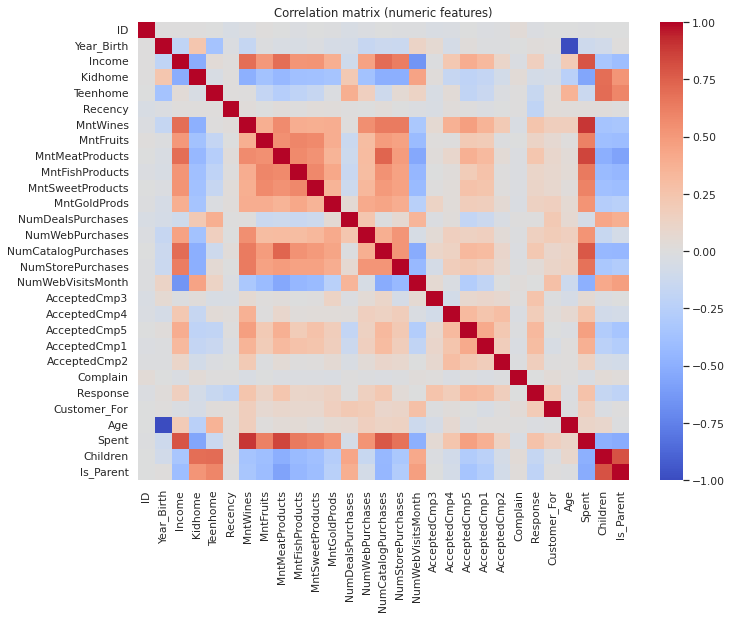

In [13]:
numeric_data = data.select_dtypes(include=[np.number])
plt.figure(figsize=(11, 9))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", center=0,
            annot=False, square=False)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout(); plt.show()

**Insight:** `Income` and `Spent` are strongly related to several purchase-count features. Also, the separate product-spending columns are strongly related to `Spent`, because `Spent` is calculated from them. To avoid using too many overlapping features, I remove the most redundant columns before clustering.

## 6. Data preprocessing

I prepare the data in two main steps:

1. **Encoding** categorical features into numeric form. `Education` has a meaningful order, and `Living_With` is binary, so label encoding is acceptable here.
2. **Scaling** all features with `StandardScaler`. This is important for K-Means because the algorithm is based on distances. Without scaling, large-range features such as `Income` could dominate smaller-range features such as `Children`.

I also remove features that overlap too much with the newly created variables. This keeps the final clustering data cleaner and easier to interpret.


In [14]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
for col in ["Education", "Living_With"]:
    data[col] = LabelEncoder().fit_transform(data[col])

# Columns to drop before clustering
drop_cols = ["ID", "Dt_Customer", "Year_Birth", "Marital_Status",
             "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4",
             "AcceptedCmp5", "Complain", "Response",
             "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
             "MntSweetProducts", "MntGoldProds",
             "Kidhome", "Teenhome", "Family_Size"]

cluster_features = data.drop(columns=drop_cols)
print("Features used for clustering:")
print(list(cluster_features.columns))

Features used for clustering:
['Education', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Customer_For', 'Age', 'Spent', 'Living_With', 'Children', 'Is_Parent']


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_ds = pd.DataFrame(scaler.fit_transform(cluster_features),
                         columns=cluster_features.columns)
scaled_ds.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Is_Parent
0,-0.893586,0.287105,0.310353,0.351030,1.426865,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.581139
1,-0.893586,-0.260882,-0.380813,-0.168701,-1.126420,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.632456
2,-0.893586,0.913196,-0.795514,-0.688432,1.426865,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-1.581139
3,-0.893586,-1.176114,-0.795514,-0.168701,-0.761665,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.632456
4,0.571657,0.294307,1.554453,1.390492,0.332600,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.632456


## 7. Finding the optimal number of clusters

I use two common methods, both calculated on the **scaled data**, which is also the data used for the final clustering model.

- **Elbow method**: shows how inertia changes as the number of clusters increases. I look for the point where adding more clusters gives only a small improvement.
- **Silhouette score**: measures how well the clusters are separated. A higher score usually means better separation.


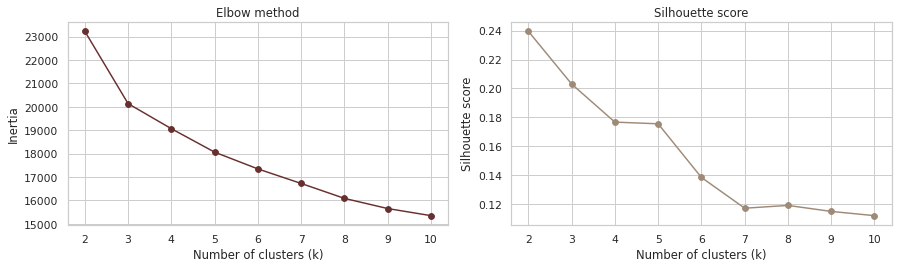

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K = range(2, 11)
inertia, sil_scores = [], []
for k in K:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(scaled_ds)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_ds, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(K, inertia, "o-", color="#682F2F")
ax[0].set_title("Elbow method"); ax[0].set_xlabel("Number of clusters (k)"); ax[0].set_ylabel("Inertia")
ax[1].plot(K, sil_scores, "o-", color="#9F8A78")
ax[1].set_title("Silhouette score"); ax[1].set_xlabel("Number of clusters (k)"); ax[1].set_ylabel("Silhouette score")
plt.tight_layout(); plt.show()

**Insight:** The elbow starts to flatten around k = 3. The silhouette score is higher for very small k values, but **k = 3** gives a better balance between separation and practical business interpretation. Three segments are also easier to explain and act on, so I continue with **k = 3**.

## 8. Building the K-Means model

I fit K-Means with k = 3 on the **scaled data** (`scaled_ds`). PCA is used later only for 2D visualization. The actual clustering is done on all scaled features, so the model can use the full information available in the dataset.


In [17]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
data["Cluster"] = kmeans.fit_predict(scaled_ds)

print("Customers per cluster:")
print(data["Cluster"].value_counts().sort_index())

Customers per cluster:
Cluster
0     521
1     686
2    1005
Name: count, dtype: int64


## 9. Cluster analysis and visualization

### 9.1 Visualizing the clusters in 2D with PCA

The dataset has many features, so it cannot be plotted directly in two dimensions. I use **PCA** to reduce the scaled features to 2 components only for visualization. This helps us see the general separation between the clusters.


Variance explained by the 2 components: [0.322 0.142] (total 0.463 )


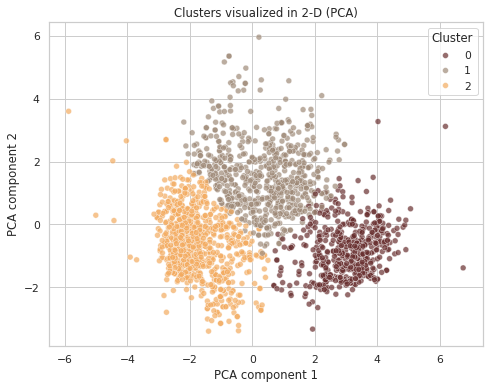

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(scaled_ds)
print("Variance explained by the 2 components:",
      pca.explained_variance_ratio_.round(3),
      "(total", round(pca.explained_variance_ratio_.sum(), 3), ")")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=data["Cluster"],
                palette=["#682F2F", "#9F8A78", "#F3AB60"], alpha=0.7)
plt.title("Clusters visualized in 2-D (PCA)")
plt.xlabel("PCA component 1"); plt.ylabel("PCA component 2")
plt.legend(title="Cluster")
plt.show()

### 9.2 Cluster sizes and key features

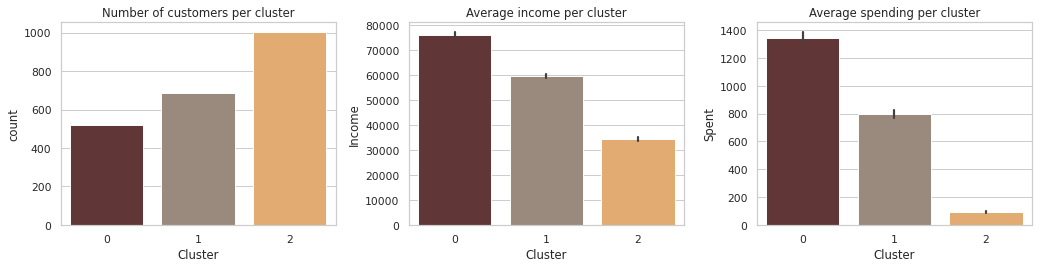

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
pal = ["#682F2F", "#9F8A78", "#F3AB60"]
sns.countplot(x="Cluster", data=data, hue="Cluster", palette=pal, legend=False, ax=ax[0])
ax[0].set_title("Number of customers per cluster")
sns.barplot(x="Cluster", y="Income", data=data, hue="Cluster", palette=pal, legend=False, ax=ax[1])
ax[1].set_title("Average income per cluster")
sns.barplot(x="Cluster", y="Spent", data=data, hue="Cluster", palette=pal, legend=False, ax=ax[2])
ax[2].set_title("Average spending per cluster")
plt.tight_layout(); plt.show()

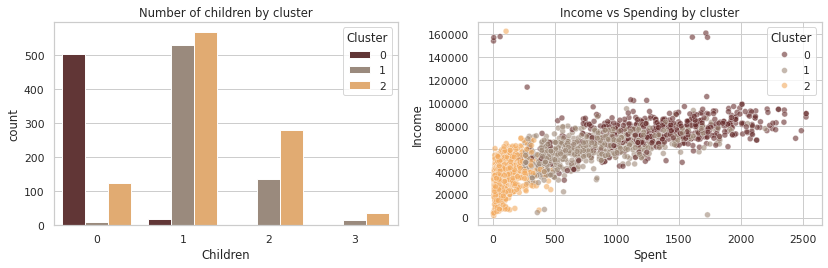

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Children", hue="Cluster", data=data, palette=pal, ax=ax[0])
ax[0].set_title("Number of children by cluster")
sns.scatterplot(x="Spent", y="Income", hue="Cluster", data=data, palette=pal, alpha=0.6, ax=ax[1])
ax[1].set_title("Income vs Spending by cluster")
plt.tight_layout(); plt.show()

### 9.3 Cluster profiles

In [21]:
profile = data.groupby("Cluster")[["Income", "Spent", "Age", "Children", "Is_Parent"]].mean().round(0)
profile["count"] = data["Cluster"].value_counts().sort_index()
profile["percent"] = (profile["count"] / len(data) * 100).round(1)
profile

,Income,Spent,Age,Children,Is_Parent,count,percent
Cluster,,,,,,,
0,76031.0,1347.0,46.0,0.0,0.0,521,23.6
1,59570.0,798.0,48.0,1.0,1.0,686,31.0
2,34285.0,94.0,42.0,1.0,1.0,1005,45.4


Based on the table above, the three customer segments can be described as follows:

**Cluster 0: Affluent high spenders, about 24% of customers**
- Highest average income, around 76,000.
- Highest spending level, around 1,350.
- Mostly customers without children at home.
- This looks like a premium segment with strong purchasing power.

**Cluster 1: Mid-income parents, about 31% of customers**
- Middle income level, around 60,000.
- Moderate spending level, around 800.
- Mostly parents, often with one child.
- This is a stable family-oriented segment.

**Cluster 2: Budget-conscious parents, about 45% of customers**
- Lowest average income, around 34,000.
- Very low spending level, around 90.
- Mostly parents with children at home.
- This is the largest group and looks more price-sensitive.

Note: K-Means assigns cluster numbers randomly. The meaning of each cluster comes from the profile, not from the number itself.


## Conclusion

Using K-Means clustering, I divided the customers into **three main groups**: affluent high spenders, mid-income parents, and budget-conscious parents. The strongest separating factors were income, total spending, and family situation.

The main technical steps were feature engineering, scaling before clustering, choosing the number of clusters with Elbow and Silhouette methods, fitting K-Means on the full scaled data, and using PCA only to visualize the result in 2D.

**Business value:** These segments can help a company design more targeted marketing strategies. For example, premium offers can be aimed at the affluent segment, while value-based campaigns may work better for the budget-conscious segment.
